In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [82]:
path="/content/aluminum_wire_rod_synthetic_10000.csv"

In [83]:
df=pd.read_csv(path)

In [84]:
df.head()

,Casting_Temperature_C,Rolling_Speed_m_min,Cooling_Rate_C_s,UTS_MPa,Elongation_%,Conductivity_%_IACS
0,697.718136,163.643838,39.712249,500.711414,78.081272,54.282260
1,714.057005,142.242639,34.400726,511.514986,79.159096,54.244548
2,716.629472,131.062094,38.224224,515.505950,79.558297,54.199773
3,692.591177,146.584556,29.936551,505.424829,76.581255,54.635314
4,706.830214,129.944941,31.104307,515.491479,78.649964,54.109156


In [85]:
df.describe()

,Casting_Temperature_C,Rolling_Speed_m_min,Cooling_Rate_C_s,UTS_MPa,Elongation_%,Conductivity_%_IACS
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,714.771513,150.230753,32.501840,512.285332,79.853869,54.147138
std,14.361105,17.339264,4.310463,10.275373,1.757382,0.536160
min,690.000582,120.009465,25.000722,479.358287,73.820515,52.221457
25%,702.367430,135.273602,28.788982,505.102034,78.563676,53.790899
50%,714.648492,150.276050,32.536330,512.197925,79.861369,54.150055
75%,727.081496,165.322198,36.199823,519.498231,81.142111,54.508449
max,739.977885,179.995490,39.998515,545.434224,85.853594,56.112975


In [86]:
df.shape

(10000, 6)

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Casting_Temperature_C  10000 non-null  float64
 1   Rolling_Speed_m_min    10000 non-null  float64
 2   Cooling_Rate_C_s       10000 non-null  float64
 3   UTS_MPa                10000 non-null  float64
 4   Elongation_%           10000 non-null  float64
 5   Conductivity_%_IACS    10000 non-null  float64
dtypes: float64(6)
memory usage: 468.9 KB


In [88]:
df.isnull().sum()

,0
Casting_Temperature_C,0
Rolling_Speed_m_min,0
Cooling_Rate_C_s,0
UTS_MPa,0
Elongation_%,0
Conductivity_%_IACS,0


In [89]:
df.corr()

,Casting_Temperature_C,Rolling_Speed_m_min,Cooling_Rate_C_s,UTS_MPa,Elongation_%,Conductivity_%_IACS
Casting_Temperature_C,1.000000,-0.012781,-0.007655,0.708904,0.815638,0.003993
Rolling_Speed_m_min,-0.012781,1.000000,-0.018316,-0.516436,0.002123,-0.315252
Cooling_Rate_C_s,-0.007655,-0.018316,1.000000,0.008965,-0.125775,0.178201
UTS_MPa,0.708904,-0.516436,0.008965,1.000000,0.574342,0.163177
Elongation_%,0.815638,0.002123,-0.125775,0.574342,1.000000,-0.018288
Conductivity_%_IACS,0.003993,-0.315252,0.178201,0.163177,-0.018288,1.000000


<Axes: >

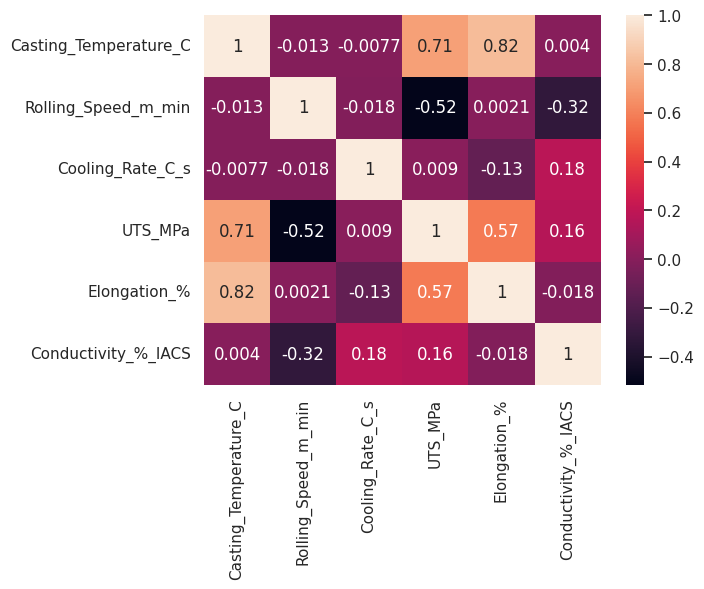

In [90]:
sns.heatmap(df.corr(),annot=True)

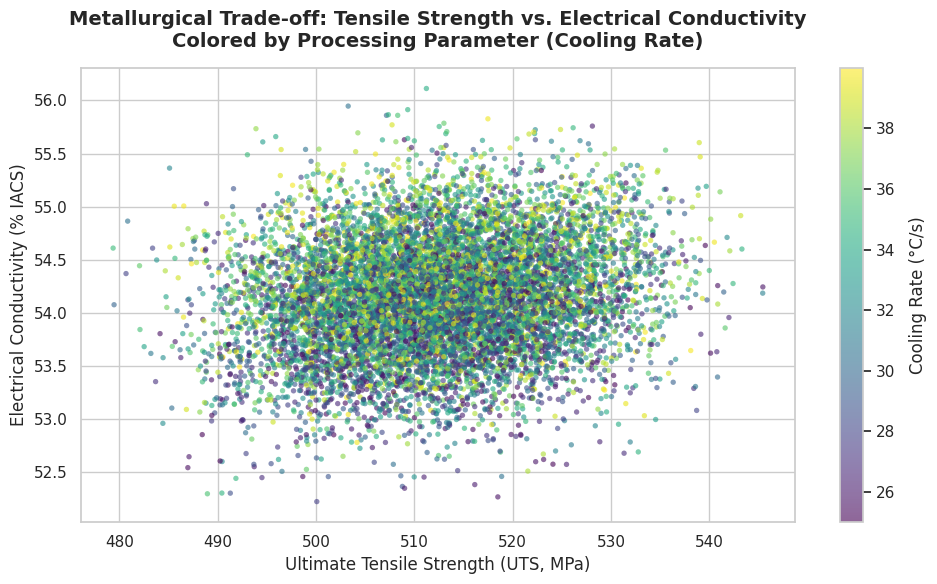

In [91]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    data=df,
    x="UTS_MPa",
    y="Conductivity_%_IACS",
    c="Cooling_Rate_C_s",
    cmap="viridis",
    alpha=0.6,
    edgecolors="none",
    s=15
)

plt.xlabel("Ultimate Tensile Strength (UTS, MPa)", fontsize=12)
plt.ylabel("Electrical Conductivity (% IACS)", fontsize=12)
plt.title(
    "Metallurgical Trade-off: Tensile Strength vs. Electrical Conductivity\n"
    "Colored by Processing Parameter (Cooling Rate)",
    fontsize=14,
    fontweight='bold',
    pad=15
)

cbar = plt.colorbar(scatter)
cbar.set_label("Cooling Rate (°C/s)", fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()

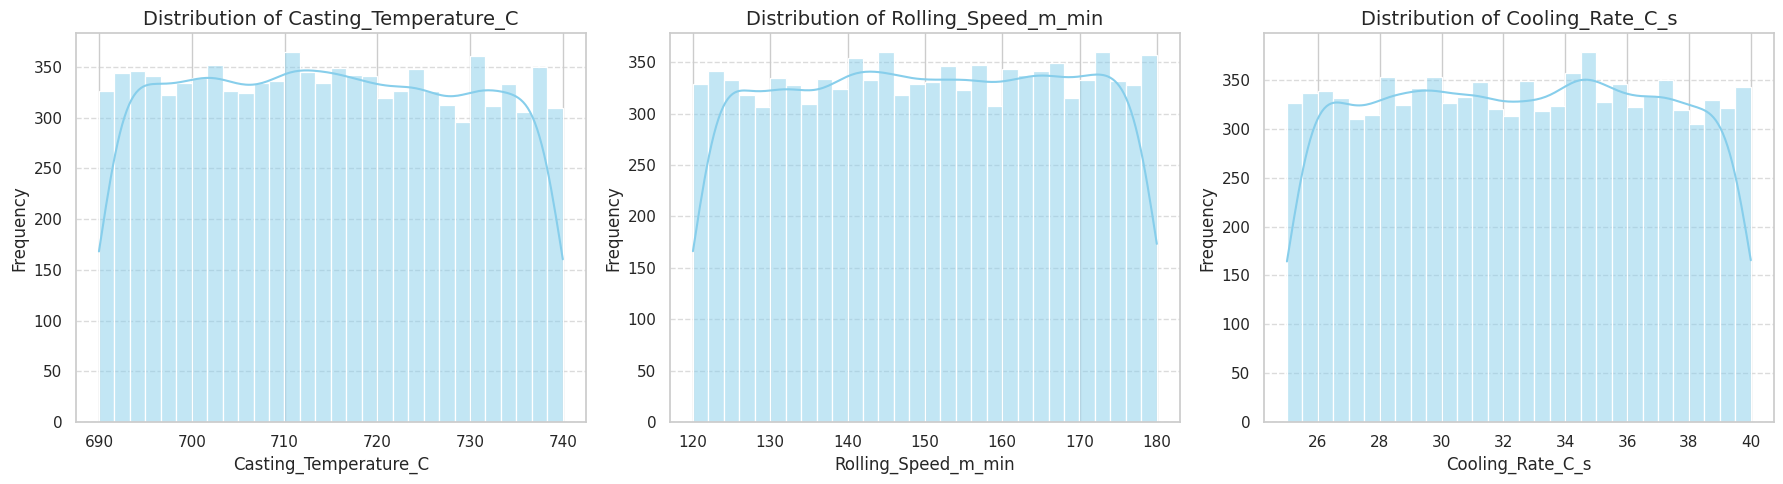

In [92]:
features = ['Casting_Temperature_C', 'Rolling_Speed_m_min', 'Cooling_Rate_C_s']

plt.figure(figsize=(18, 5)) # Adjust figure size to accommodate three subplots

for i, feature in enumerate(features):
    plt.subplot(1, 3, i + 1) # Create 1 row, 3 columns of subplots
    sns.histplot(df[feature], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {feature}', fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

#Features are Uniformly Distributed


In [93]:
X= df[['Casting_Temperature_C','Rolling_Speed_m_min','Cooling_Rate_C_s']]

In [94]:
y=df[['UTS_MPa','Elongation_%','Conductivity_%_IACS']]

In [95]:
from sklearn.model_selection import train_test_split

In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

In [97]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 3), (2000, 3), (8000, 3), (2000, 3))

In [98]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit_transform(X_train)
x_test=scaler.transform(X_test)


In [99]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [100]:
baseline_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("Training baseline Random Forest multi-output regressor...")
baseline_rf.fit(X_train, y_train)
print("Training complete.\n")

# 3. Generate Predictions on the held-out test set
y_pred = baseline_rf.predict(X_test)

# 4. Evaluate and Tabulate Performance Metrics Separately for each target property
print(f"{'Target Property':<25} | {'R² Score':<10} | {'MAE':<10} | {'RMSE':<10}")
print("-" * 65)

# Loop through each target column name and index to compute metrics
for i, target_col in enumerate(y.columns):
    actuals = y_test.iloc[:, i]
    predictions = y_pred[:, i]

    # Calculate performance metrics
    r2 = r2_score(actuals, predictions)
    mae = mean_absolute_error(actuals, predictions)
    rmse = np.sqrt(mean_squared_error(actuals, predictions))

    print(f"{target_col:<25} | {r2:<10.4f} | {mae:<10.4f} | {rmse:<10.4f}")

print("-" * 65)
print("Action Item: Save these baseline scores to compare against your tuned models later!")

Training baseline Random Forest multi-output regressor...
Training complete.

Target Property           | R² Score   | MAE        | RMSE      
-----------------------------------------------------------------
UTS_MPa                   | 0.7364     | 4.2621     | 5.3308    
Elongation_%              | 0.6347     | 0.8544     | 1.0749    
Conductivity_%_IACS       | 0.0397     | 0.4103     | 0.5207    
-----------------------------------------------------------------
Action Item: Save these baseline scores to compare against your tuned models later!


In [101]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

In [102]:
base_estimator = HistGradientBoostingRegressor(
    max_iter=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

In [103]:
advanced_model = MultiOutputRegressor(base_estimator)

print("Training advanced Gradient Boosted MultiOutput pipeline...")
advanced_model.fit(X_train, y_train)
print("Training complete.\n")

# 3. Generate Predictions
y_pred_adv = advanced_model.predict(X_test)

# 4. Evaluate and Tabulate Performance Metrics
print(f"{'Target Property':<25} | {'Adv R² Score':<12} | {'Adv MAE':<10} | {'Adv RMSE':<10}")
print("-" * 70)

for i, target_col in enumerate(y.columns):
    actuals = y_test.iloc[:, i]
    predictions = y_pred_adv[:, i]

    r2 = r2_score(actuals, predictions)
    mae = mean_absolute_error(actuals, predictions)
    rmse = np.sqrt(mean_squared_error(actuals, predictions))

    print(f"{target_col:<25} | {r2:<12.4f} | {mae:<10.4f} | {rmse:<10.4f}")

print("-" * 70)

Training advanced Gradient Boosted MultiOutput pipeline...
Training complete.

Target Property           | Adv R² Score | Adv MAE    | Adv RMSE  
----------------------------------------------------------------------
UTS_MPa                   | 0.7651       | 4.0444     | 5.0320    
Elongation_%              | 0.6658       | 0.8216     | 1.0281    
Conductivity_%_IACS       | 0.1206       | 0.3920     | 0.4983    
----------------------------------------------------------------------


In [104]:
from xgboost import XGBRegressor


In [105]:
base_xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1  # Uses all available CPU cores for parallel tree building
)

# 3. Wrap the XGBoost model inside the MultiOutput Meta-Estimator
# This automatically clones and trains 3 independent XGBoost models (one for each target column)
xgb_multi_output = MultiOutputRegressor(base_xgb)

print("Training MultiOutputRegressor wrapped around XGBRegressor...")
xgb_multi_output.fit(X_train, y_train)
print("Model training successfully completed.\n")

# 4. Predict on the held-out test data
y_pred_xgb = xgb_multi_output.predict(X_test)

# 5. Evaluate Performance Metrics for each metallurgical target property
print(f"{'Target Property':<25} | {'XGB R² Score':<12} | {'XGB MAE':<10} | {'XGB RMSE':<10}")
print("-" * 70)

for i, target_col in enumerate(y.columns):
    actuals = y_test.iloc[:, i]
    predictions = y_pred_xgb[:, i]

    # Calculate performance metrics
    r2 = r2_score(actuals, predictions)
    mae = mean_absolute_error(actuals, predictions)
    rmse = np.sqrt(mean_squared_error(actuals, predictions))

    print(f"{target_col:<25} | {r2:<12.4f} | {mae:<10.4f} | {rmse:<10.4f}")

print("-" * 70)

Training MultiOutputRegressor wrapped around XGBRegressor...
Model training successfully completed.

Target Property           | XGB R² Score | XGB MAE    | XGB RMSE  
----------------------------------------------------------------------
UTS_MPa                   | 0.7648       | 4.0477     | 5.0355    
Elongation_%              | 0.6642       | 0.8225     | 1.0306    
Conductivity_%_IACS       | 0.1182       | 0.3931     | 0.4990    
----------------------------------------------------------------------


In [106]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

In [107]:
# Define the parameter distribution for HistGradientBoostingRegressor
param_dist = {
    'estimator__max_iter': randint(50, 200),  # Number of boosting stages
    'estimator__learning_rate': uniform(0.01, 0.2), # Learning rate (from 0.01 to 0.21)
    'estimator__max_depth': randint(3, 10),   # Maximum depth of the individual regression estimators
    'estimator__min_samples_leaf': randint(10, 50) # Minimum number of samples required to be at a leaf node
}

# Initialize RandomizedSearchCV
# We'll use negative mean squared error as the scoring metric, as GridSearchCV/RandomizedSearchCV
# optimize for higher scores, so 'neg_mean_squared_error' is used for minimization.
random_search = RandomizedSearchCV(
    estimator=advanced_model, # Our MultiOutputRegressor with HistGradientBoostingRegressor
    param_distributions=param_dist,
    n_iter=50,  # Number of parameter settings that are sampled. Reduce for faster run, increase for better search.
    cv=5,       # 3-fold cross-validation
    scoring='neg_mean_squared_error', # Common scoring for regression
    random_state=42,
    n_jobs=-1,  # Use all available CPU cores
    verbose=1
)

print("Starting RandomizedSearchCV for hyperparameter tuning...")
random_search.fit(X_train, y_train)
print("RandomizedSearchCV complete.")

Starting RandomizedSearchCV for hyperparameter tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
RandomizedSearchCV complete.


In [108]:
print(f"Best parameters found: {random_search.best_params_}")
print(f"Best cross-validation score (negative MSE): {random_search.best_score_:.4f}")

# Get the best estimator
best_tuned_model = random_search.best_estimator_

# Make predictions with the best tuned model
y_pred_tuned = best_tuned_model.predict(X_test)

# Evaluate and Tabulate Performance Metrics for the tuned model
print("\nPerformance of Tuned Model on Test Set:")
print(f"{'Target Property':<25} | {'Tuned R² Score':<14} | {'Tuned MAE':<10} | {'Tuned RMSE':<10}")
print("-" * 78)

for i, target_col in enumerate(y.columns):
    actuals = y_test.iloc[:, i]
    predictions = y_pred_tuned[:, i]

    r2 = r2_score(actuals, predictions)
    mae = mean_absolute_error(actuals, predictions)
    rmse = np.sqrt(mean_squared_error(actuals, predictions))

    print(f"{target_col:<25} | {r2:<14.4f} | {mae:<10.4f} | {rmse:<10.4f}")

print("-" * 78)

Best parameters found: {'estimator__learning_rate': np.float64(0.0839308912122809), 'estimator__max_depth': 3, 'estimator__max_iter': 87, 'estimator__min_samples_leaf': 33}
Best cross-validation score (negative MSE): -9.0586

Performance of Tuned Model on Test Set:
Target Property           | Tuned R² Score | Tuned MAE  | Tuned RMSE
------------------------------------------------------------------------------
UTS_MPa                   | 0.7663         | 4.0342     | 5.0197    
Elongation_%              | 0.6693         | 0.8171     | 1.0227    
Conductivity_%_IACS       | 0.1220         | 0.3921     | 0.4979    
------------------------------------------------------------------------------


Residual Analysis for the Best Tuned Model


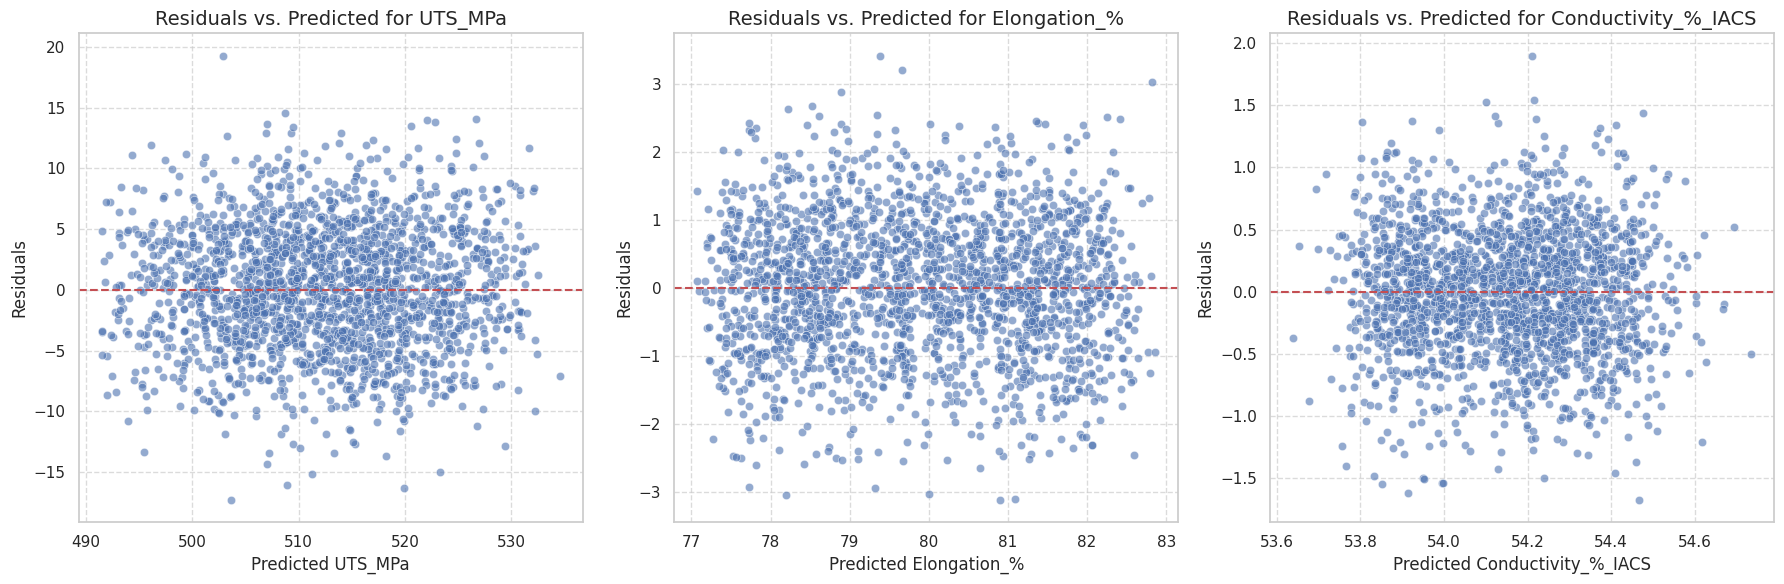

In [109]:
residuals = y_test - y_pred_tuned

# Get the names of the target columns
target_cols = y.columns

plt.figure(figsize=(18, 6)) # Adjust figure size for multiple plots

for i, target_col in enumerate(target_cols):
    plt.subplot(1, len(target_cols), i + 1) # Create subplots for each target
    sns.scatterplot(x=y_pred_tuned[:, i], y=residuals.iloc[:, i], alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title(f'Residuals vs. Predicted for {target_col}', fontsize=14)
    plt.xlabel(f'Predicted {target_col}', fontsize=12)
    plt.ylabel('Residuals', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Generating SHAP summary plots...

SHAP values for target: UTS_MPa


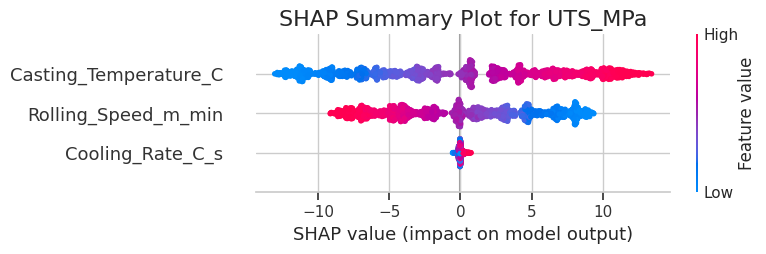


SHAP values for target: Elongation_%


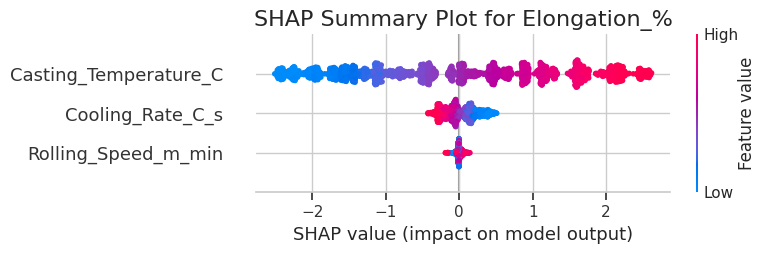


SHAP values for target: Conductivity_%_IACS


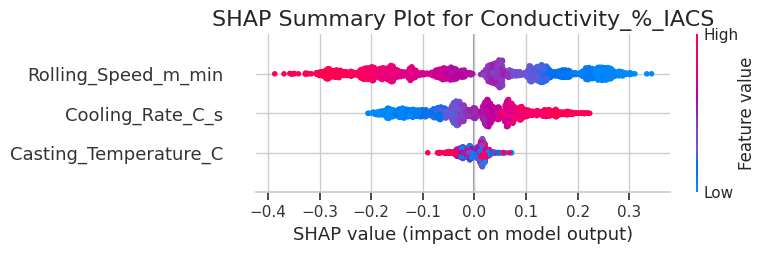

In [116]:
import shap

# The best_tuned_model is a MultiOutputRegressor, which contains multiple estimators.
# We need to analyze each estimator separately or use a wrapper.
# For tree-based models like HistGradientBoostingRegressor, TreeExplainer is suitable.

# Since MultiOutputRegressor trains a separate model for each output,
# we need to access them. They are usually stored in `best_tuned_model.estimators_`
# if the `fit` method has been called.

explainer_list = [shap.TreeExplainer(est) for est in best_tuned_model.estimators_]
shap_values_list = [explainer.shap_values(X_test) for explainer in explainer_list]

# Get the names of the target columns
target_cols = y.columns

print("Generating SHAP summary plots...")

for i, target_col in enumerate(target_cols):
    print(f"\nSHAP values for target: {target_col}")
    # The shap_values for TreeExplainer on a single output model is a 2D array (samples, features)
    shap.summary_plot(shap_values_list[i], X_test, feature_names=X.columns, show=False)
    plt.title(f'SHAP Summary Plot for {target_col}', fontsize=16)
    plt.tight_layout()
    plt.savefig(f'shap_summary_plot_{target_col}.png')
    plt.show()